# Train a Vision Transformer (ViT) — surface maps → depth temperatures

**Idea:** split each day's surface map into **patches**, run a **Transformer** over those tokens, then rebuild temperatures at 15 depths.

| Piece | Shape (TF channels-last) | Meaning |
|-------|--------------------------|--------|
| Input X | `(100, 240, 8)` | 8 surface fields |
| Target Y | `(100, 240, 15)` | `thetao` at 15 depths |
| Mask | `(100, 240, 15)` | 1 = valid ocean label |

Data: **Jan–Mar (JFM) 2015–2024** (`train_daily_JFM_2015_2024`, 903 days) · time split 80/20 · masked MSE + ridge + early stopping.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# --- Apple Silicon GPU (Metal) ---
# Needs: pip install tensorflow-metal  (same env as tensorflow)
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for g in gpus:
        try:
            tf.config.experimental.set_memory_growth(g, True)
        except Exception as e:
            print("memory_growth:", e)
    print(f"Metal GPU enabled: {len(gpus)} device(s) →", gpus)
else:
    print(
        "No GPU found — install Apple Metal plugin in THIS kernel env:\n"
        "  %pip install tensorflow-metal\n"
        "then restart the kernel and re-run this cell."
    )

import xarray as xr

ROOT = Path("../..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA = ROOT / "data" / "processed" / "train_daily_JFM_2015_2024"
RUN_TAG = "jfm_2015_2024"
CKPT_DIR = ROOT / "ml" / "checkpoints"
OUT = ROOT / "outputs" / "vit"
CKPT_DIR.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

CHANNELS = ["sst", "sss", "sla", "adt", "uo", "vo", "u10", "v10"]
print("TensorFlow:", tf.__version__)
print("ROOT:", ROOT)
print("DATA:", DATA)
print("devices:", tf.config.list_physical_devices())


/Users/sayangarai/Documents/Programming/Data Science/ml_env/mlenv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow: 2.20.0
ROOT: /Users/sayangarai/Documents/Programming/Projects/SIH_PS_26066
DATA: /Users/sayangarai/Documents/Programming/Projects/SIH_PS_26066/data/processed/train_daily_JFM_2015_2024
devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [2]:
# --- Small ViT (defined in-notebook; no .py model file) ---
from tensorflow import keras
from tensorflow.keras import layers, regularizers


class PatchEmbed(layers.Layer):
    def __init__(self, patch_size, embed_dim, l2=0.0, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.proj = layers.Conv2D(
            embed_dim, kernel_size=patch_size, strides=patch_size, padding="valid",
            kernel_regularizer=regularizers.l2(l2) if l2 > 0 else None,
        )

    def call(self, x):
        x = self.proj(x)
        b = tf.shape(x)[0]
        return tf.reshape(x, (b, -1, self.embed_dim))


class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1, l2=0.0, **kwargs):
        super().__init__(**kwargs)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=max(embed_dim // num_heads, 1), dropout=dropout,
            kernel_regularizer=regularizers.l2(l2) if l2 > 0 else None,
        )
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        reg = regularizers.l2(l2) if l2 > 0 else None
        self.fc1 = layers.Dense(mlp_dim, activation="gelu", kernel_regularizer=reg)
        self.drop1 = layers.Dropout(dropout)
        self.fc2 = layers.Dense(embed_dim, kernel_regularizer=reg)
        self.drop2 = layers.Dropout(dropout)

    def call(self, x, training=None):
        y = self.attn(self.norm1(x), self.norm1(x), training=training)
        x = x + y
        y = self.fc1(self.norm2(x))
        y = self.drop1(y, training=training)
        y = self.fc2(y)
        y = self.drop2(y, training=training)
        return x + y


class SmallViT(keras.Model):
    def __init__(
        self, in_ch=8, out_ch=15, patch_size=10, embed_dim=128, depth=4,
        num_heads=4, mlp_dim=256, dropout=0.1, l2=1e-4, max_tokens=512, **kwargs,
    ):
        super().__init__(**kwargs)
        self.out_ch = out_ch
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.patch_embed = PatchEmbed(patch_size, embed_dim, l2=l2)
        self.pos_embed = layers.Embedding(max_tokens, embed_dim)
        self.blocks = [
            TransformerBlock(embed_dim, num_heads, mlp_dim, dropout=dropout, l2=l2)
            for _ in range(depth)
        ]
        self.encoder_norm = layers.LayerNormalization(epsilon=1e-6)
        reg = regularizers.l2(l2) if l2 > 0 else None
        self.head = layers.Dense(patch_size * patch_size * out_ch, kernel_regularizer=reg)
        self.refine = layers.Conv2D(out_ch, 3, padding="same", kernel_regularizer=reg)

    def call(self, inputs, training=None):
        patch = self.patch_size
        h0, w0 = tf.shape(inputs)[1], tf.shape(inputs)[2]
        pad_h = (patch - h0 % patch) % patch
        pad_w = (patch - w0 % patch) % patch
        x = tf.pad(inputs, [[0, 0], [0, pad_h], [0, pad_w], [0, 0]])
        hp, wp = tf.shape(x)[1] // patch, tf.shape(x)[2] // patch
        tokens = self.patch_embed(x)
        n = tf.shape(tokens)[1]
        tokens = tokens + self.pos_embed(tf.range(n))
        for block in self.blocks:
            tokens = block(tokens, training=training)
        tokens = self.encoder_norm(tokens)
        pixels = self.head(tokens)
        pixels = tf.reshape(pixels, (-1, hp, wp, patch, patch, self.out_ch))
        pixels = tf.transpose(pixels, [0, 1, 3, 2, 4, 5])
        logits = tf.reshape(pixels, (-1, hp * patch, wp * patch, self.out_ch))
        logits = self.refine(logits)
        return logits[:, :h0, :w0, :]


## 1. Load cubes & time split


In [3]:
surface = xr.open_dataset(DATA / "surface.nc", engine="h5netcdf")
target = xr.open_dataset(DATA / "target.nc", engine="h5netcdf")

n_days = surface.sizes["time"]
n_train = int(n_days * 0.8)
train_idx = np.arange(0, n_train)
val_idx = np.arange(n_train, n_days)

print(f"days: {n_days}  train: {len(train_idx)}  val: {len(val_idx)}")
print("train:", str(surface.time.values[train_idx[0]])[:10], "→", str(surface.time.values[train_idx[-1]])[:10])
print("val:  ", str(surface.time.values[val_idx[0]])[:10], "→", str(surface.time.values[val_idx[-1]])[:10])
print("depths:", target.depth.values.tolist())


days: 903  train: 722  val: 181
train: 2015-01-01 → 2022-03-31
val:   2023-01-01 → 2024-03-31
depths: [0.0, 5.0, 10.0, 20.0, 30.0, 50.0, 75.0, 100.0, 125.0, 150.0, 200.0, 300.0, 500.0, 700.0, 1000.0]


## 2. Normalize (train ocean pixels only)


In [4]:
def channel_mean_std(arr: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    c = arr.shape[-1]
    mean = np.zeros(c, dtype=np.float32)
    std = np.ones(c, dtype=np.float32)
    for i in range(c):
        vals = arr[..., i][np.isfinite(arr[..., i])]
        if vals.size:
            mean[i] = vals.mean()
            s = vals.std()
            std[i] = s if s > 1e-6 else 1.0
    return mean, std


x_all = np.stack([surface[name].values for name in CHANNELS], axis=-1).astype(np.float32)
y_all = np.moveaxis(target.thetao.values.astype(np.float32), 1, -1)

x_mean, x_std = channel_mean_std(x_all[train_idx])
y_mean, y_std = channel_mean_std(y_all[train_idx])

print("X", x_all.shape, "Y", y_all.shape)
print("Y mean (by depth):", np.round(y_mean, 2))

X (903, 100, 240, 8) Y (903, 100, 240, 15)
Y mean (by depth): [27.24 27.16 27.22 27.26 27.26 26.99 25.82 23.49 20.85 18.57 15.67 13.13
 11.22  9.78  8.39]


## 3. `tf.data` pipeline


In [5]:
def make_example(t: int):
    x = x_all[t].copy()
    y = y_all[t].copy()
    x_ok = np.all(np.isfinite(x), axis=-1)
    y_ok = np.isfinite(y)
    mask = y_ok & x_ok[..., None]

    x = (x - x_mean) / x_std
    y = (y - y_mean) / y_std
    x = np.nan_to_num(x, nan=0.0).astype(np.float32)
    y = np.nan_to_num(y, nan=0.0).astype(np.float32)
    return x, y, mask.astype(np.float32)


def make_dataset(indices: np.ndarray, training: bool, batch_size: int = 4) -> tf.data.Dataset:
    xs, ys, ms = [], [], []
    for t in indices:
        x, y, m = make_example(int(t))
        xs.append(x)
        ys.append(y)
        ms.append(m)
    ds = tf.data.Dataset.from_tensor_slices((np.stack(xs), np.stack(ys), np.stack(ms)))
    if training:
        ds = ds.shuffle(len(indices), reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


BATCH = 4
train_ds = make_dataset(train_idx, training=True, batch_size=BATCH)
val_ds = make_dataset(val_idx, training=False, batch_size=BATCH)

xb, yb, mb = next(iter(train_ds))
print("batch X", xb.shape, "Y", yb.shape, "mask", mb.shape)
print("mask ocean fraction", float(tf.reduce_mean(mb)))

batch X (4, 100, 240, 8) Y (4, 100, 240, 15) mask (4, 100, 240, 15)
mask ocean fraction 0.4159388840198517


## 4. ViT model + masked MSE + ridge

- **Patch size 10** → about `10×24 = 240` tokens on a 100×240 map
- Transformer depth 4, embed 128, 4 heads
- Decode tokens back to a 15-channel map, then a light refine conv


In [6]:
def masked_mse(y_true, y_pred, mask):
    diff2 = tf.square(y_pred - y_true)
    return tf.reduce_sum(diff2 * mask) / tf.maximum(tf.reduce_sum(mask), 1.0)


def ridge_loss():
    if model.losses:
        return tf.add_n(model.losses)
    return tf.constant(0.0)


L2 = 1e-4
model = SmallViT(
    in_ch=8,
    out_ch=15,
    patch_size=10,
    embed_dim=128,
    depth=4,
    num_heads=4,
    mlp_dim=256,
    dropout=0.1,
    l2=L2,
)
optimizer = tf.keras.optimizers.Adam(5e-4)

out = model(xb[:1], training=False)
n_params = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
print("forward out:", tuple(out.shape))
print(f"params: {n_params:,}  L2={L2}  n_reg_terms={len(model.losses)}")
model.summary()

forward out: (1, 100, 240, 15)
params: 893,780  L2=0.0001  n_reg_terms=27


Model: "small_vi_t"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ patch_embed (PatchEmbed)        │ ?                      │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (240, 128)             │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ ?                      │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ ?                      │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ ?                      │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ ?                      │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_8           │ (1, 240, 128)          │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (1, 240, 1500)         │       193,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 100, 240, 15)      │         2,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 893,780 (3.41 MB)

 Trainable params: 893,780 (3.41 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Train with early stopping


In [7]:
EPOCHS = 60
PATIENCE = 6
best_weights = CKPT_DIR / f"vit_{RUN_TAG}_best.weights.h5"
norm_path = CKPT_DIR / f"vit_{RUN_TAG}_norm.npz"

np.savez(
    norm_path,
    x_mean=x_mean,
    x_std=x_std,
    y_mean=y_mean,
    y_std=y_std,
    channels=np.array(CHANNELS),
    depths=target.depth.values.astype(np.float32),
    l2=np.float32(L2),
)


@tf.function
def train_step(x, y, mask):
    with tf.GradientTape() as tape:
        pred = model(x, training=True)
        data_loss = masked_mse(y, pred, mask)
        reg_loss = ridge_loss()
        loss = data_loss + reg_loss
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, data_loss, reg_loss


@tf.function
def val_step(x, y, mask):
    pred = model(x, training=False)
    data_loss = masked_mse(y, pred, mask)
    return data_loss + ridge_loss(), data_loss


history = {"loss": [], "val_loss": [], "data_loss": [], "reg_loss": [], "val_data_loss": []}
best_val = float("inf")
wait = 0

for epoch in range(1, EPOCHS + 1):
    tr_sum = tr_data = tr_reg = 0.0
    tr_n = 0
    for x, y, m in train_ds:
        loss, dloss, rloss = train_step(x, y, m)
        bs = int(x.shape[0])
        tr_sum += float(loss) * bs
        tr_data += float(dloss) * bs
        tr_reg += float(rloss) * bs
        tr_n += bs
    train_loss = tr_sum / max(tr_n, 1)
    train_data = tr_data / max(tr_n, 1)
    train_reg = tr_reg / max(tr_n, 1)

    va_sum = va_data = 0.0
    va_n = 0
    for x, y, m in val_ds:
        loss, dloss = val_step(x, y, m)
        bs = int(x.shape[0])
        va_sum += float(loss) * bs
        va_data += float(dloss) * bs
        va_n += bs
    val_loss = va_sum / max(va_n, 1)
    val_data = va_data / max(va_n, 1)

    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["data_loss"].append(train_data)
    history["reg_loss"].append(train_reg)
    history["val_data_loss"].append(val_data)

    star = ""
    if val_loss < best_val - 1e-5:
        best_val = val_loss
        wait = 0
        star = " *best*"
        model.save_weights(best_weights)
    else:
        wait += 1

    print(
        f"epoch {epoch:02d}  train={train_loss:.4f} (data={train_data:.4f} ridge={train_reg:.4f})  "
        f"val={val_loss:.4f} (data={val_data:.4f})  wait={wait}/{PATIENCE}{star}"
    )
    if wait >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

model.load_weights(best_weights)
print(f"restored best val={best_val:.4f}")
print("weights:", best_weights)


2026-08-30 07:02:07.592837: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-08-30 07:02:09.053910: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


epoch 01  train=0.4130 (data=0.2513 ridge=0.1618)  val=0.3121 (data=0.1749)  wait=0/6 *best*


2026-08-30 07:02:19.297079: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


epoch 02  train=0.2576 (data=0.1380 ridge=0.1196)  val=0.2540 (data=0.1501)  wait=0/6 *best*
epoch 03  train=0.2130 (data=0.1210 ridge=0.0920)  val=0.2222 (data=0.1409)  wait=0/6 *best*


2026-08-30 07:02:40.141397: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


epoch 04  train=0.1842 (data=0.1114 ridge=0.0728)  val=0.2101 (data=0.1450)  wait=0/6 *best*
epoch 05  train=0.1633 (data=0.1044 ridge=0.0589)  val=0.1911 (data=0.1379)  wait=0/6 *best*
epoch 06  train=0.1503 (data=0.1016 ridge=0.0487)  val=0.1779 (data=0.1333)  wait=0/6 *best*
epoch 07  train=0.1383 (data=0.0972 ridge=0.0411)  val=0.1717 (data=0.1337)  wait=0/6 *best*


2026-08-30 07:03:23.078354: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


epoch 08  train=0.1295 (data=0.0941 ridge=0.0354)  val=0.1661 (data=0.1331)  wait=0/6 *best*
epoch 09  train=0.1212 (data=0.0903 ridge=0.0309)  val=0.1600 (data=0.1310)  wait=0/6 *best*
epoch 10  train=0.1165 (data=0.0891 ridge=0.0274)  val=0.1542 (data=0.1283)  wait=0/6 *best*
epoch 11  train=0.1107 (data=0.0861 ridge=0.0247)  val=0.1525 (data=0.1291)  wait=0/6 *best*
epoch 12  train=0.1077 (data=0.0853 ridge=0.0224)  val=0.1550 (data=0.1335)  wait=1/6
epoch 13  train=0.1033 (data=0.0825 ridge=0.0207)  val=0.1448 (data=0.1249)  wait=0/6 *best*
epoch 14  train=0.1002 (data=0.0809 ridge=0.0192)  val=0.1429 (data=0.1243)  wait=0/6 *best*
epoch 15  train=0.0997 (data=0.0815 ridge=0.0181)  val=0.1487 (data=0.1310)  wait=1/6


2026-08-30 07:04:53.450709: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


epoch 16  train=0.0973 (data=0.0799 ridge=0.0174)  val=0.1466 (data=0.1297)  wait=2/6
epoch 17  train=0.0956 (data=0.0789 ridge=0.0166)  val=0.1486 (data=0.1323)  wait=3/6
epoch 18  train=0.0942 (data=0.0781 ridge=0.0161)  val=0.1443 (data=0.1285)  wait=4/6
epoch 19  train=0.0922 (data=0.0765 ridge=0.0157)  val=0.1398 (data=0.1243)  wait=0/6 *best*
epoch 20  train=0.0893 (data=0.0741 ridge=0.0152)  val=0.1427 (data=0.1277)  wait=1/6
epoch 21  train=0.0881 (data=0.0733 ridge=0.0148)  val=0.1469 (data=0.1322)  wait=2/6
epoch 22  train=0.0884 (data=0.0739 ridge=0.0145)  val=0.1412 (data=0.1267)  wait=3/6
epoch 23  train=0.0867 (data=0.0723 ridge=0.0144)  val=0.1479 (data=0.1336)  wait=4/6
epoch 24  train=0.0875 (data=0.0733 ridge=0.0142)  val=0.1360 (data=0.1218)  wait=0/6 *best*
epoch 25  train=0.0852 (data=0.0710 ridge=0.0142)  val=0.1428 (data=0.1288)  wait=1/6
epoch 26  train=0.0846 (data=0.0707 ridge=0.0140)  val=0.1399 (data=0.1259)  wait=2/6
epoch 27  train=0.0829 (data=0.0690 ridg

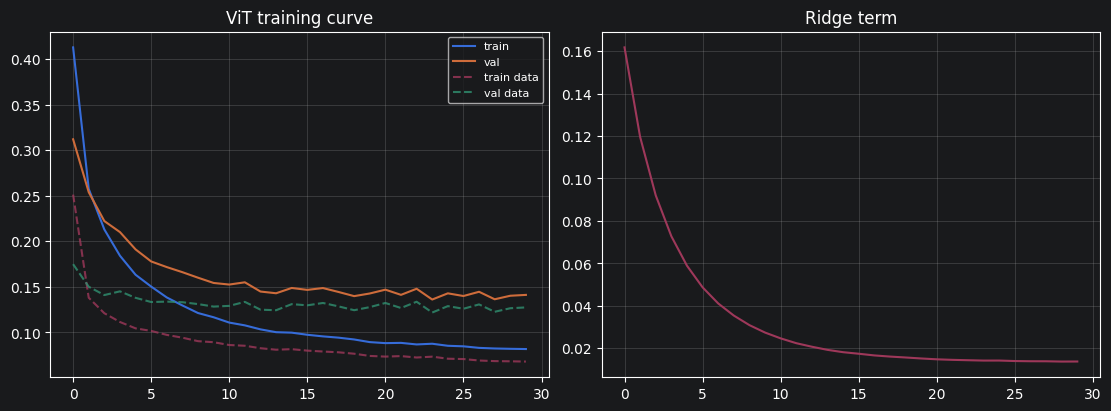

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(history["loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].plot(history["data_loss"], "--", label="train data", alpha=0.8)
axes[0].plot(history["val_data_loss"], "--", label="val data", alpha=0.8)
axes[0].set_title("ViT training curve")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[1].plot(history["reg_loss"], color="C2")
axes[1].set_title("Ridge term")
axes[1].grid(True, alpha=0.3)
fig.savefig(OUT / "01_loss_curve.png", dpi=140)
plt.show()

## 6. Evaluate in °C


Validation RMSE (°C) by depth:
       0 m  0.344 °C
       5 m  0.347 °C
      10 m  0.344 °C
      20 m  0.373 °C
      30 m  0.431 °C
      50 m  0.598 °C
      75 m  0.891 °C
     100 m  1.107 °C
     125 m  1.091 °C
     150 m  0.954 °C
     200 m  0.652 °C
     300 m  0.499 °C
     500 m  0.359 °C
     700 m  0.352 °C
    1000 m  0.361 °C
mean RMSE: 0.580 °C
overall RMSE: 0.635 °C


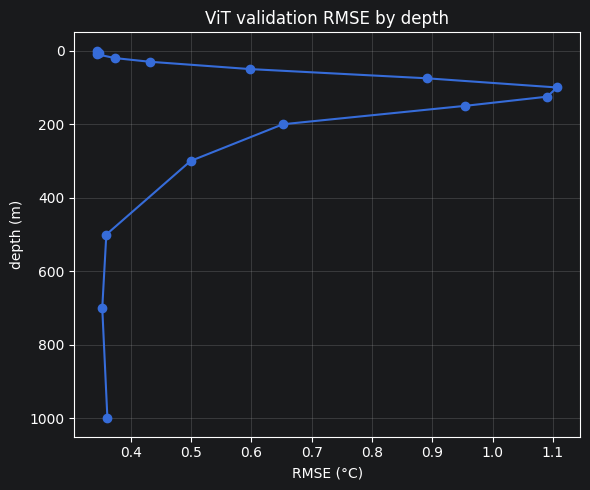

In [9]:
model.load_weights(best_weights)
norm = np.load(norm_path)
y_mean = norm["y_mean"]
y_std = norm["y_std"]
depths = norm["depths"]

sse = np.zeros(15, dtype=np.float64)
count = np.zeros(15, dtype=np.float64)

for x, y_n, m in val_ds:
    pred_n = model(x, training=False).numpy()
    y_n = y_n.numpy()
    m = m.numpy()
    pred = pred_n * y_std + y_mean
    y = y_n * y_std + y_mean
    err2 = (pred - y) ** 2 * m
    sse += err2.sum(axis=(0, 1, 2))
    count += m.sum(axis=(0, 1, 2))

rmse = np.sqrt(sse / np.maximum(count, 1.0))
print("Validation RMSE (°C) by depth:")
for d, r in zip(depths, rmse):
    print(f"  {float(d):6.0f} m  {r:.3f} °C")
print(f"mean RMSE: {rmse.mean():.3f} °C")
print(f"overall RMSE: {np.sqrt(sse.sum() / count.sum()):.3f} °C")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rmse, depths, marker="o")
ax.invert_yaxis()
ax.set_xlabel("RMSE (°C)")
ax.set_ylabel("depth (m)")
ax.set_title("ViT validation RMSE by depth")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "02_rmse_by_depth.png", dpi=140)
plt.show()


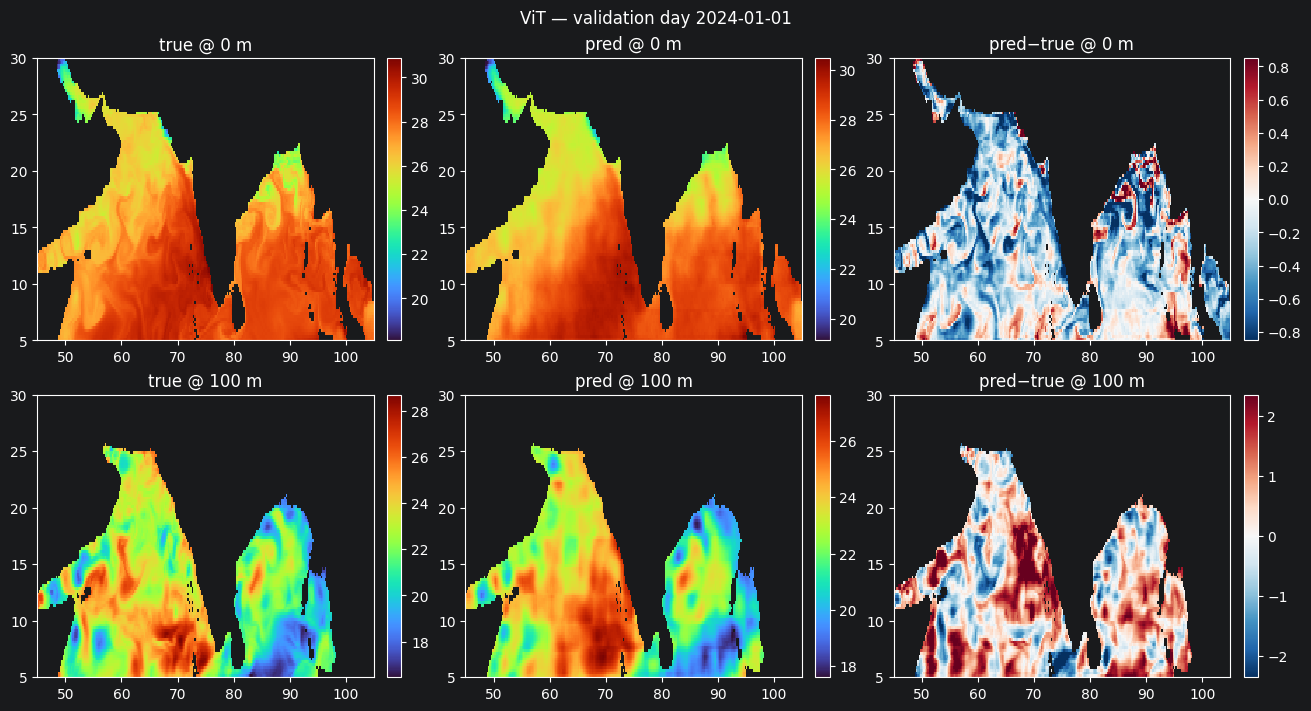

In [10]:
vi = len(val_idx) // 2
val_day = int(val_idx[vi])
x1, _, m1 = make_example(val_day)

pred_n = model(x1[None, ...], training=False).numpy()[0]
pred_c = pred_n * y_std + y_mean
true_c = y_all[val_day]

lon = surface.longitude.values
lat = surface.latitude.values
day_label = str(surface.time.values[val_day])[:10]

fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)
for row, d in enumerate([0.0, 100.0]):
    di = int(np.where(depths == d)[0][0])
    truth = np.where(m1[..., di], true_c[..., di], np.nan)
    pred = np.where(m1[..., di], pred_c[..., di], np.nan)
    err = pred - truth
    for ax, field, title in zip(
        axes[row],
        [truth, pred, err],
        [f"true @ {d:.0f} m", f"pred @ {d:.0f} m", f"pred−true @ {d:.0f} m"],
    ):
        if "pred−true" in title:
            vmax = np.nanpercentile(np.abs(err), 95)
            im = ax.pcolormesh(lon, lat, field, shading="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        else:
            im = ax.pcolormesh(lon, lat, field, shading="auto", cmap="turbo")
        ax.set_title(title)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f"ViT — validation day {day_label}")
fig.savefig(OUT / "03_maps_true_pred.png", dpi=140)
plt.show()

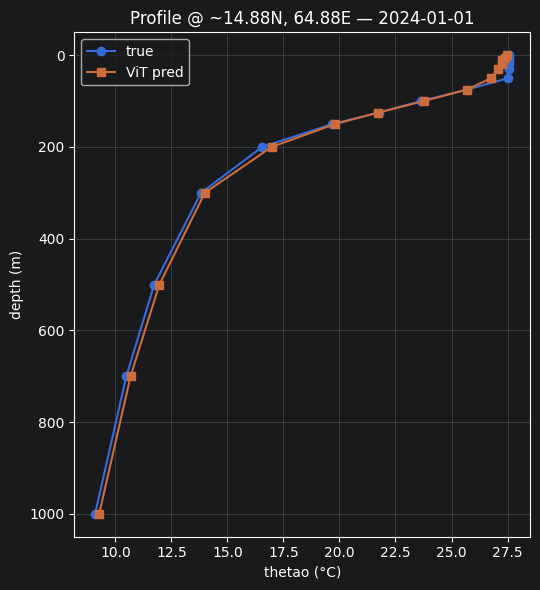

In [11]:
lat0, lon0 = 15.0, 65.0
j = int(np.argmin(np.abs(lat - lat0)))
i = int(np.argmin(np.abs(lon - lon0)))

fig, ax = plt.subplots(figsize=(5.5, 6))
ax.plot(true_c[j, i, :], depths, marker="o", label="true")
ax.plot(pred_c[j, i, :], depths, marker="s", label="ViT pred")
ax.invert_yaxis()
ax.set_xlabel("thetao (°C)")
ax.set_ylabel("depth (m)")
ax.set_title(f"Profile @ ~{lat[j]:.2f}N, {lon[i]:.2f}E — {day_label}")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "04_profile.png", dpi=140)
plt.show()

## 7. Predict any day (e.g. March 2024)

Set `PRED_DATE` to any date in the JFM cube (requires trained weights). Uses the same normalization stats saved during training.

ViT prediction — 2024-03-15
       0 m  0.344 °C
       5 m  0.365 °C
      10 m  0.374 °C
      20 m  0.382 °C
      30 m  0.462 °C
      50 m  0.729 °C
      75 m  0.959 °C
     100 m  1.078 °C
     125 m  1.120 °C
     150 m  1.065 °C
     200 m  0.717 °C
     300 m  0.552 °C
     500 m  0.391 °C
     700 m  0.390 °C
    1000 m  0.378 °C
overall RMSE: 0.675 °C


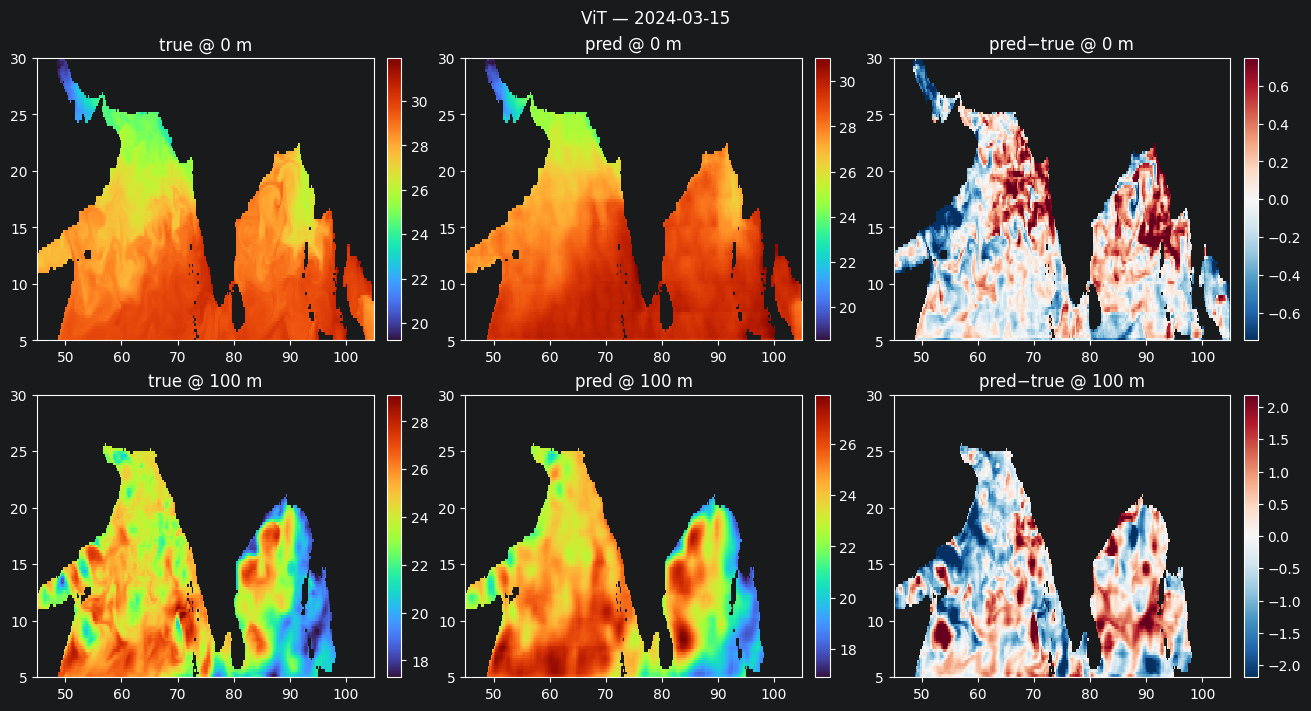

saved: /Users/sayangarai/Documents/Programming/Projects/SIH_PS_26066/outputs/vit/predict_2024-03-15/maps_surface_100m.png


In [12]:
PRED_DATE = "2024-03-15"  # any day in surface.nc, e.g. all of March 2024

model.load_weights(best_weights)
times = surface.time.values.astype("datetime64[D]")
day_idx = int(np.where(times.astype(str) == PRED_DATE)[0][0])

x = np.stack([surface[name].values[day_idx] for name in CHANNELS], axis=-1).astype(np.float32)
y = np.moveaxis(target.thetao.values[day_idx].astype(np.float32), 0, -1)
x_ok = np.all(np.isfinite(x), axis=-1)
y_ok = np.isfinite(y)
mask = (y_ok & x_ok[..., None]).astype(np.float32)

x_n = np.nan_to_num((x - x_mean) / x_std, nan=0.0).astype(np.float32)
pred_n = model(x_n[None], training=False).numpy()[0]
pred_c = pred_n * y_std + y_mean
true_c = y

diff2 = np.where(mask, (pred_c - true_c) ** 2, 0.0)
rmse_d = np.sqrt(diff2.sum(axis=(0, 1)) / np.maximum(mask.sum(axis=(0, 1)), 1.0))
print(f"ViT prediction — {PRED_DATE}")
for d, r in zip(target.depth.values, rmse_d):
    print(f"  {float(d):6.0f} m  {r:.3f} °C")
print(f"overall RMSE: {np.sqrt(diff2.sum() / mask.sum()):.3f} °C")

pred_out = OUT / f"predict_{PRED_DATE}"
pred_out.mkdir(parents=True, exist_ok=True)
lon, lat = surface.longitude.values, surface.latitude.values

fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)
for row, d in enumerate([0.0, 100.0]):
    di = int(np.where(target.depth.values == d)[0][0])
    truth = np.where(mask[..., di], true_c[..., di], np.nan)
    pred = np.where(mask[..., di], pred_c[..., di], np.nan)
    err = pred - truth
    for ax, field, title in zip(
        axes[row], [truth, pred, err],
        [f"true @ {d:.0f} m", f"pred @ {d:.0f} m", f"pred−true @ {d:.0f} m"],
    ):
        if "pred−true" in title:
            vmax = np.nanpercentile(np.abs(err), 95)
            im = ax.pcolormesh(lon, lat, field, shading="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        else:
            im = ax.pcolormesh(lon, lat, field, shading="auto", cmap="turbo")
        ax.set_title(title)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"ViT — {PRED_DATE}")
fig.savefig(pred_out / "maps_surface_100m.png", dpi=140)
plt.show()
print("saved:", pred_out / "maps_surface_100m.png")

## Artifacts

- Model: `in-notebook SmallViT` (`SmallViT`)
- Weights: `ml/checkpoints/vit_jfm_2015_2024_best.weights.h5`
- Norm: `ml/checkpoints/vit_jfm_2015_2024_norm.npz`
- Figures: `outputs/vit/`

Compare against `train_convlstm_lag.ipynb` (use closed-loop §6 for daily ops).
